<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Benchmark 3 - TPeanuts Pipeline Profiler
---

This notebook profiles the torch-native `tpeanuts` solar-to-detector pipeline stage by stage: solar production, Earth matter propagation, and the combined chain. Unlike `benchmark1`/`benchmark2` (which measure wall-clock time against a reference implementation), this notebook does not compare against anything — its only goal is to locate *where inside tpeanuts* the time and function-call cost actually go, at both the Python-function level and the PyTorch-operation level.

The companion notebook `benchmark4_peanuts_profiler.ipynb` performs the analogous profiling for the legacy `peanuts` implementation, with the additional Numba-specific considerations that library requires.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: profiling methodology, tool selection, and what "bottleneck" means here |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** - paths, parameters, shared objects, and profiling helpers |
| [3](#3.-Solar-Production-Stage) | **Solar Production Stage** |
| [4](#4.-Earth-Propagation-Stage) | **Earth Propagation Stage** |
| [5](#5.-Solar-to-Detector-Chain) | **Solar-to-Detector Chain** |
| [6](#6.-Operation-Level-Profiling) | **Operation-Level Profiling** (`torch.profiler`) |
| [7](#7.-Case-A-vs-Case-B) | **Case A vs Case B**: effect of detector depth on Earth-propagation cost |
| [8](#8.-Bottleneck-Scaling-with-Grid-Size) | **Bottleneck Scaling with Grid Size** |
| [9](#9.-Summary) | **Summary**: ranked bottlenecks across every profiled scenario |

## 0. Theory Background

### 0.1 What This Notebook Measures

`benchmark1`/`benchmark2` answer "is tpeanuts faster than X?". This notebook answers a different question: "inside tpeanuts itself, which function or operation consumes the time?". The two views used here are complementary:

- **Python-function level** (`cProfile`): counts calls and attributes wall-clock time to each Python function in the call tree, distinguishing *self* time (`tottime`, time spent in the function's own body) from *cumulative* time (`cumtime`, time spent in the function plus everything it calls). `tottime` is what tells you which function is the actual bottleneck rather than just a wrapper around one.
- **Tensor-operation level** (`torch.profiler`): counts and times individual PyTorch kernel dispatches (`pow`, `exp`, `einsum`, `linalg.eigh`, ...). This distinguishes real numerical cost (large tensors, expensive kernels) from Python/dispatch overhead (many small tensor operations, each cheap in isolation but numerous).

A batched, vectorized library like `tpeanuts` can be dominated by either regime depending on grid size: at small grids, per-call Python/dispatch overhead dominates regardless of how little data is actually being processed; at large grids, the real per-element numerical cost dominates. Distinguishing the two is the point of profiling stage by stage instead of only end to end.

### 0.2 Methodology

Every profiled call follows the same protocol:

1. **Warm-up** — run the target function a few times before profiling, so first-call effects (module import, lazy tensor allocation, cache population) are not attributed to steady-state cost.
2. **Repeat** — profile many repeated calls (rather than one), since `cProfile`'s per-call overhead is itself non-negligible and a single call is noisy.
3. **Sort by `tottime`** to find the actual bottleneck function, and by `cumtime` to see which branch of the call tree it lives under.

### 0.3 Pipeline Stages Profiled

| Stage | Function |
|-------|----------|
| Solar production | `solar_probability_state` (mass-basis weights + PMNS projection) |
| Earth propagation | `earth_probability_state` (perturbative Earth evolutor + projection) |
| Solar-to-detector chain | `solar_probability_mass` followed by `earth_probability_state` |

---

**References**

- Python Software Foundation, `cProfile` and `pstats` — deterministic Python profiling.
- PyTorch documentation, `torch.profiler` — operation-level CPU/CUDA profiling.

## 1. Libraries

In [1]:
from __future__ import annotations

import cProfile
import pstats
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.profiler import ProfilerActivity, profile
from IPython.display import display

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.profile import SolarParameters, SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_state, solar_probability_mass
from tpeanuts.util.context import RuntimeContext

print(f"Torch version : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Torch version : 2.5.1
CUDA available: True


## 2. Paths and Configuration

### 2.1 Paths

Same shared notebook configuration as the other benchmark notebooks. Outputs are saved under `benchmark/`.

In [2]:
config = load_notebook_config()

PACKAGE_DIR = config.package_dir
DATA_DIR = config.data_dir
OUTPUT_DIR = config.output_dir("benchmark")

EARTH_DENSITY_TPEANUTS = str(DATA_DIR / "earth" / "prem" / "fit" / "even_power_electron.csv")
SOLAR_DENSITY_CSV_FILE = str(DATA_DIR / "solar" / "bahcall" / "density" / "bp2000_density_electron_neutron_monotonic.csv")
SOLAR_FLUX_CSV_FILE = str(DATA_DIR / "solar" / "bahcall" / "flux" / "fluxes_bahcall_bp2004.csv")

print(f"PACKAGE_DIR = {PACKAGE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output directory: v:\output\benchmark


### 2.2 Configuration

Oscillation parameters, Earth/solar profiles, and grid sizes used throughout this notebook. Grid sizes are chosen to be large enough that the profiled calls are dominated by real work rather than pure `cProfile`/warm-up noise, while still completing in a reasonable time.

In [3]:
DEVICE = config.device
DTYPE = torch.float32
SHOW_PLOTS = config.show_plots

context = RuntimeContext.resolve(DEVICE, DTYPE)
oscillation = PropagationConfig.oscillation_parameters_from_preset(context=context, antinu=False)

earth_profile_t = EarthProfile(
    params=EarthParameters(
        profile_perturbative_kwargs={"density_file": EARTH_DENSITY_TPEANUTS, "tabulated_density": False},
    ),
    context=context,
)
solar_profile = SolarProfile.default(
    params=SolarParameters(density_path=SOLAR_DENSITY_CSV_FILE, fluxes_path=SOLAR_FLUX_CSV_FILE),
    context=context,
)

SOLAR_SOURCE = "8B"
EARTH_DEPTH_M = 0.0
SOLAR_DETECTOR_DEPTH_M = 1000.0
MASS_WEIGHTS = torch.tensor([0.20, 0.30, 0.50], dtype=DTYPE, device=DEVICE)

# Grid sizes for the main stage-by-stage profiles.
LARGE_NE = 256
LARGE_NETA = 128

PROFILE_REPEATS = 25
PROFILE_WARMUPS = 5

print("Configuration loaded.")
print(f"  LARGE_NE={LARGE_NE}, LARGE_NETA={LARGE_NETA}")
print(f"  PROFILE_REPEATS={PROFILE_REPEATS}, PROFILE_WARMUPS={PROFILE_WARMUPS}")

Configuration loaded.
  LARGE_NE=256, LARGE_NETA=128
  PROFILE_REPEATS=25, PROFILE_WARMUPS=5


### 2.3 Profiling Helpers

`profile_function` runs the standard warm-up + repeat protocol under `cProfile` and returns a `pstats.Stats` object. `stats_to_dataframe` turns that into a tidy, sortable `DataFrame`. `profile_torch_ops` does the same at the tensor-operation level with `torch.profiler`.

In [4]:
def profile_function(func, *, repeats=None, warmups=None):
    # Warm up, then profile `repeats` calls to `func` with cProfile.
    repeats = PROFILE_REPEATS if repeats is None else repeats
    warmups = PROFILE_WARMUPS if warmups is None else warmups
    for _ in range(warmups):
        func()
    profiler = cProfile.Profile()
    profiler.enable()
    for _ in range(repeats):
        func()
    profiler.disable()
    return pstats.Stats(profiler)


def stats_to_dataframe(stats, *, limit=20, sort_by="tottime"):
    # Flatten a pstats.Stats object into a tidy DataFrame.
    items = sorted(
        stats.stats.items(),
        key=lambda kv: kv[1][2 if sort_by == "tottime" else 3],
        reverse=True,
    )
    rows = []
    for (filename, lineno, funcname), (cc, nc, tt, ct, _callers) in items[:limit]:
        short_file = Path(filename).name if filename not in ("~", "") else filename
        rows.append({
            "function": funcname,
            "file": short_file,
            "line": lineno,
            "ncalls": nc,
            "tottime_s": tt,
            "percall_tot_ms": (tt / nc * 1.0e3) if nc else 0.0,
            "cumtime_s": ct,
            "percall_cum_ms": (ct / cc * 1.0e3) if cc else 0.0,
            "location": f"{funcname} ({short_file}:{lineno})",
        })
    df = pd.DataFrame(rows)
    df.attrs["total_tottime_s"] = stats.total_tt
    return df


def plot_top_functions(df, title, filename, *, metric="tottime_s", top=15):
    # Horizontal bar chart of the top functions by the chosen metric.
    d = df.sort_values(metric, ascending=True).tail(top)
    fig, ax = plt.subplots(figsize=(9.5, 0.38 * len(d) + 1.5))
    ax.barh(d["location"], d[metric], color="C0")
    ax.set_xlabel(metric)
    ax.set_title(title)
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


def profile_torch_ops(func, *, repeats=None, warmups=None):
    # Warm up, then profile `repeats` calls to `func` with torch.profiler.
    repeats = PROFILE_REPEATS if repeats is None else repeats
    warmups = PROFILE_WARMUPS if warmups is None else warmups
    for _ in range(warmups):
        func()
    with profile(activities=[ProfilerActivity.CPU]) as prof:
        for _ in range(repeats):
            func()
    return prof


def torch_stats_to_dataframe(prof, *, limit=20):
    # Flatten torch.profiler key_averages() into a tidy DataFrame (seconds).
    rows = []
    for e in prof.key_averages():
        rows.append({
            "op": e.key,
            "count": e.count,
            "self_cpu_time_s": e.self_cpu_time_total / 1.0e6,
            "cpu_time_s": e.cpu_time_total / 1.0e6,
        })
    df = pd.DataFrame(rows).sort_values("self_cpu_time_s", ascending=False).head(limit)
    return df.reset_index(drop=True)


def plot_top_ops(df, title, filename, *, metric="self_cpu_time_s", top=15):
    # Horizontal bar chart of the top torch operations by the chosen metric.
    d = df.sort_values(metric, ascending=True).tail(top)
    fig, ax = plt.subplots(figsize=(9.5, 0.38 * len(d) + 1.5))
    ax.barh(d["op"], d[metric], color="C1")
    ax.set_xlabel(metric)
    ax.set_title(title)
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


print("Profiling helpers defined.")

Profiling helpers defined.


## 3. Solar Production Stage

Profiles `solar_probability_state` (solar mass-basis production followed by the vacuum PMNS flavour projection) over a large energy grid.

**Expected results:** the top `tottime` entries should be the matter-mixing trigonometric evaluations (`th12_M`, `th13_M`, `Vk`) and the radius-integral (`torch.trapz`) calls in `solar_probability_mass`, not Python-level looping — the whole energy grid is evaluated in one batched call.

,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,<built-in method torch.trapz>,~,0,50,0.047898,0.957952,0.047898,0.957952
1,solar_probability_mass,probability.py,192,25,0.031275,1.250988,0.263490,10.539608
2,<method 'pow' of 'torch._C.TensorBase' objects>,~,0,425,0.020743,0.048808,0.020743,0.048808
3,<built-in method torch.cos>,~,0,275,0.018621,0.067713,0.018621,0.067713
4,th12_M,matter_mixing.py,209,25,0.017864,0.714556,0.077908,3.116320
5,kinetic_potential,potential.py,165,50,0.016827,0.336548,0.019102,0.382042
6,<built-in method torch.sin>,~,0,250,0.013726,0.054903,0.013726,0.054903
7,<built-in method torch.remainder>,~,0,50,0.013466,0.269322,0.013466,0.269322
8,<built-in method torch.stack>,~,0,25,0.012955,0.518216,0.012955,0.518216
9,_rot,pmns.py,274,75,0.010578,0.141033,0.018568,0.247575


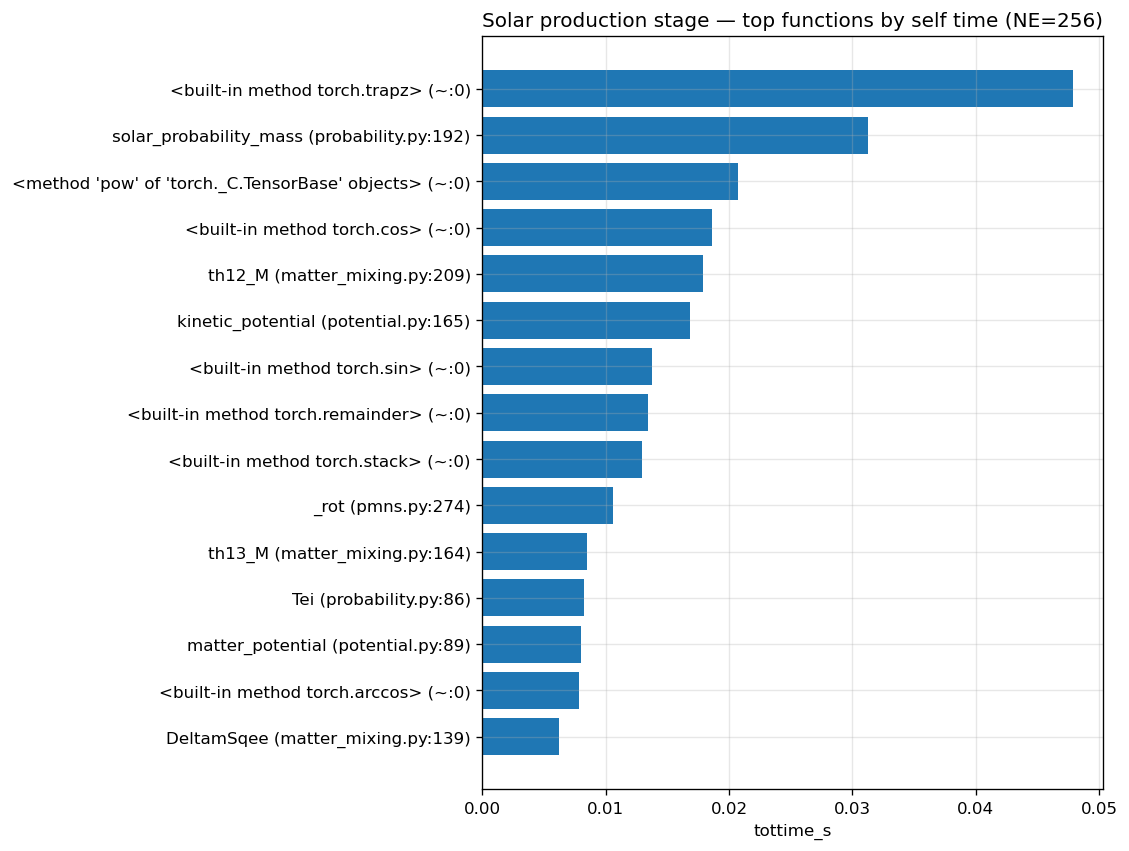

v:\output\benchmark\profiler_solar_top_functions.png


In [5]:
E_solar = torch.linspace(0.5, 15.0, LARGE_NE, dtype=DTYPE, device=DEVICE)

solar_stats = profile_function(lambda: solar_probability_state(oscillation, E_solar, solar_profile, SOLAR_SOURCE))
solar_df = stats_to_dataframe(solar_stats, limit=20, sort_by="tottime")
display(solar_df.drop(columns="location"))
plot_top_functions(solar_df, f"Solar production stage — top functions by self time (NE={LARGE_NE})",
                    "profiler_solar_top_functions.png")

## 4. Earth Propagation Stage

Profiles `earth_probability_state` (perturbative analytical Earth evolutor + projection) over a large energy/nadir grid, at the surface detector depth used by the pure Earth-propagation benchmarks in `benchmark1`.

**Expected results:** the top entries should include the spectral/perturbative evolutor machinery (`evolutor_first_order`, `residual_integral`, `hamiltonian_spectral_projectors_traceless`) and PMNS rotation construction (`_rot`).

,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,<built-in method torch._C._linalg.linalg_eigva...,~,0,50,2.391307,47.826134,2.391307,47.826134
1,oscillatory_even_monomial_integrals,profile_segment.py,377,50,0.941305,18.826098,1.273416,25.468318
2,residual_integral,profile_segment.py,451,50,0.569065,11.381298,2.375422,47.508444
3,hamiltonian_spectral_projectors_traceless,spectral.py,183,50,0.444823,8.896468,0.491280,9.825598
4,<built-in method torch.exp>,~,0,250,0.315605,1.262420,0.315605,1.262420
5,<built-in method torch.where>,~,0,775,0.253092,0.326571,0.253092,0.326571
6,<built-in method torch.abs>,~,0,225,0.199436,0.886383,0.199436,0.886383
7,<method 'sum' of 'torch._C.TensorBase' objects>,~,0,100,0.144140,1.441397,0.144140,1.441397
8,<built-in method torch.stack>,~,0,125,0.138082,1.104654,0.138082,1.104654
9,evolutor_zero_order,evolutor.py,59,50,0.135487,2.709738,3.517717,70.354330


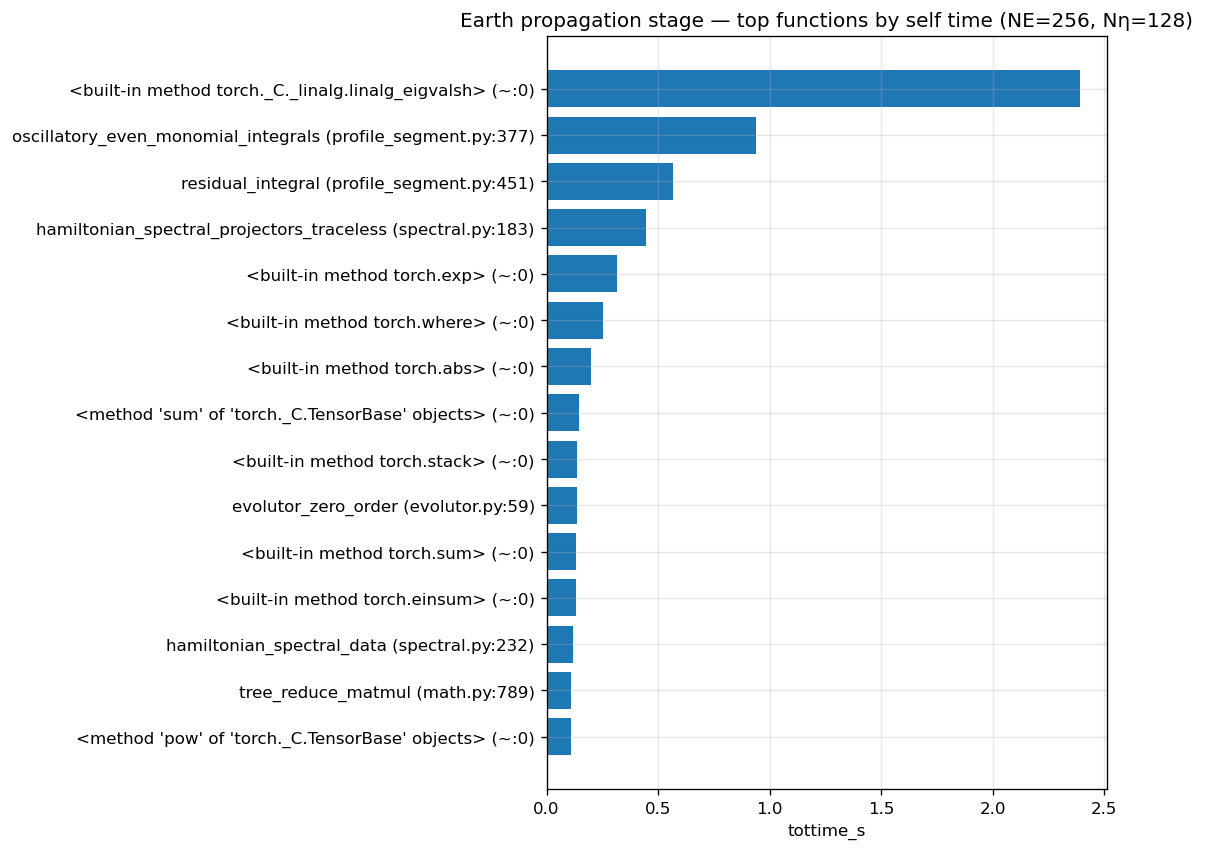

v:\output\benchmark\profiler_earth_top_functions.png


In [6]:
E_earth = torch.linspace(0.5, 15.0, LARGE_NE, dtype=DTYPE, device=DEVICE)
eta_earth = torch.linspace(0.05, torch.pi - 0.05, LARGE_NETA, dtype=DTYPE, device=DEVICE)

def earth_stage():
    return earth_probability_state(
        MASS_WEIGHTS, earth_profile_t, oscillation,
        E_earth[:, None], eta_earth[None, :], EARTH_DEPTH_M,
        method="analytical", massbasis=True, context=context,
    )

earth_stats = profile_function(earth_stage)
earth_df = stats_to_dataframe(earth_stats, limit=20, sort_by="tottime")
display(earth_df.drop(columns="location"))
plot_top_functions(earth_df, f"Earth propagation stage — top functions by self time (NE={LARGE_NE}, Nη={LARGE_NETA})",
                    "profiler_earth_top_functions.png")

## 5. Solar-to-Detector Chain

Profiles the full incoherent chain: solar mass-basis production followed by Earth propagation at the solar-detector depth (`SOLAR_DETECTOR_DEPTH_M`), matching the `benchmark1` Section 7 workflow.

**Expected results:** this should look like a mixture of Sections 3 and 4's top functions, weighted by how much time each stage actually takes relative to the other — a useful check on which of the two stages dominates the full pipeline.

,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,<built-in method torch._C._linalg.linalg_eigva...,~,0,75,2.780336,37.071149,2.780336,37.071149
1,oscillatory_even_monomial_integrals,profile_segment.py,377,50,0.946069,18.921374,1.257879,25.157572
2,residual_integral,profile_segment.py,451,50,0.533629,10.672574,2.283086,45.661716
3,hamiltonian_spectral_projectors_traceless,spectral.py,183,75,0.526335,7.017804,0.588837,7.851160
4,<built-in method torch.exp>,~,0,300,0.276715,0.922382,0.276715,0.922382
5,<built-in method torch.where>,~,0,1150,0.274414,0.238621,0.274414,0.238621
6,<built-in method torch.abs>,~,0,250,0.195065,0.780258,0.195065,0.780258
7,evolutor_zero_order,evolutor.py,59,75,0.169875,2.264997,4.173957,55.652760
8,<method 'pow' of 'torch._C.TensorBase' objects>,~,0,1300,0.159697,0.122844,0.159697,0.122844
9,hamiltonian_spectral_data,spectral.py,232,75,0.158594,2.114589,3.839701,51.196011


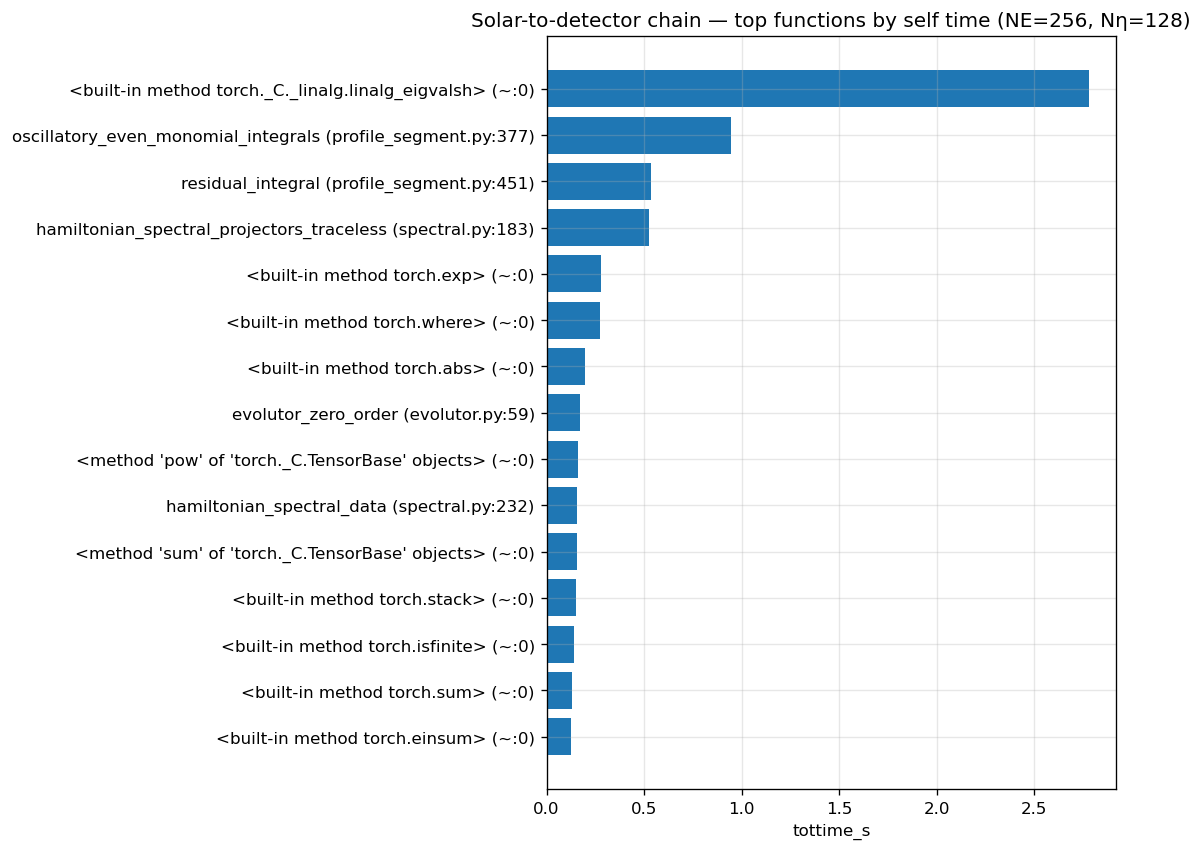

v:\output\benchmark\profiler_chain_top_functions.png
Chain total self time over 25 calls: 8.4737s (338.949 ms/call)


In [7]:
def solar_to_detector():
    mass = solar_probability_mass(oscillation, E_earth, solar_profile, SOLAR_SOURCE)
    return earth_probability_state(
        mass, earth_profile_t, oscillation,
        E_earth[:, None], eta_earth[None, :], SOLAR_DETECTOR_DEPTH_M,
        method="analytical", massbasis=True, context=context,
    )

chain_stats = profile_function(solar_to_detector)
chain_df = stats_to_dataframe(chain_stats, limit=20, sort_by="tottime")
display(chain_df.drop(columns="location"))
plot_top_functions(chain_df, f"Solar-to-detector chain — top functions by self time (NE={LARGE_NE}, Nη={LARGE_NETA})",
                    "profiler_chain_top_functions.png")

print(f"Chain total self time over {PROFILE_REPEATS} calls: {chain_stats.total_tt:.4f}s "
      f"({chain_stats.total_tt / PROFILE_REPEATS * 1e3:.3f} ms/call)")

## 6. Operation-Level Profiling

Same solar-to-detector chain as Section 5, now viewed through `torch.profiler` instead of `cProfile`. This tells us whether the time above is going into genuine tensor computation (large `self_cpu_time` on a few ops with high element counts) or dispatch overhead (many cheap ops, each with small `self_cpu_time` but a very high call `count`).

,op,count,self_cpu_time_s,cpu_time_s
0,aten::_linalg_eigh,75,2.735442,2.794975
1,aten::mul,6475,1.507036,1.536180
2,aten::add,1750,0.579045,0.599444
3,aten::sub,1050,0.407076,0.407621
4,aten::bmm,650,0.336104,0.343453
5,aten::exp,300,0.297330,0.297330
6,aten::where,1150,0.271310,0.275661
7,aten::sum,350,0.267893,0.301007
8,aten::copy_,8800,0.242498,0.242498
9,aten::div,1250,0.228291,0.235907


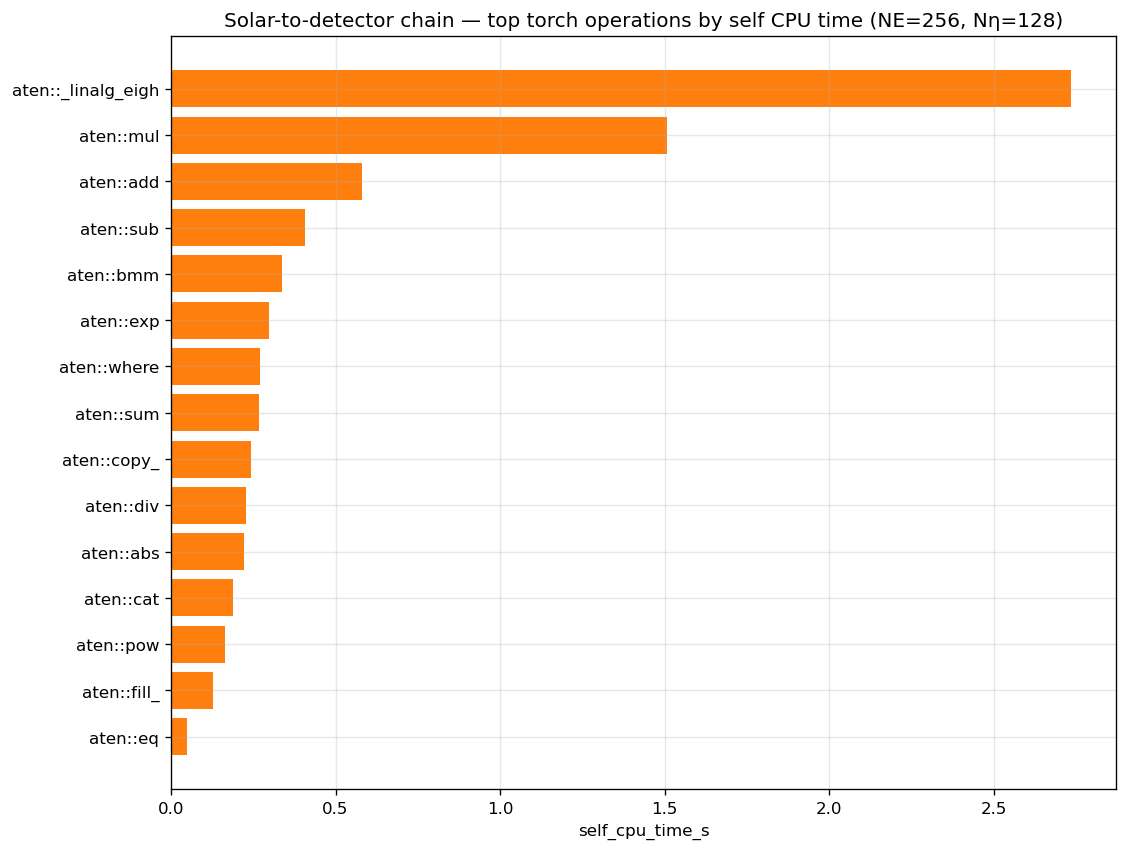

v:\output\benchmark\profiler_chain_top_ops.png
Top-20 operations account for 42850 individual dispatches over 25 calls (1714 dispatches/call).


In [8]:
chain_prof = profile_torch_ops(solar_to_detector)
chain_ops_df = torch_stats_to_dataframe(chain_prof, limit=20)
display(chain_ops_df)
plot_top_ops(chain_ops_df, f"Solar-to-detector chain — top torch operations by self CPU time (NE={LARGE_NE}, Nη={LARGE_NETA})",
             "profiler_chain_top_ops.png")

total_op_calls = int(chain_ops_df["count"].sum())
print(f"Top-20 operations account for {total_op_calls} individual dispatches "
      f"over {PROFILE_REPEATS} calls ({total_op_calls / PROFILE_REPEATS:.0f} dispatches/call).")

## 7. Case A vs Case B: Effect of Detector Depth

`earth_evolutor` dispatches each trajectory to one of two regimes depending on the nadir angle and detector depth:

- **Case A** (shell-crossing): trajectories that cross one or more tabulated Earth density shells. The density profile is non-constant, so the perturbative first-order correction (`evolutor_first_order` / `residual_integral`) is genuinely needed.
- **Case B** (shallow, detector-near): only reachable when `depth_m > 0`; the profile is approximated as constant over the short chord, so the first-order correction is analytically zero and is now skipped entirely (see the `evolutor_perturbative_from_H` optimization applied to this codebase).

This section profiles the same nadir range once with each detector depth to show how the profile changes when Case B becomes reachable.

**Expected results:** `residual_integral`/`evolutor_first_order`/`taylor_monomial_integral` should appear prominently for the Case-A-only grid, and should be absent (or far less prominent) once the grid includes Case-B trajectories at `depth_m > 0`.

In [9]:
CASE_NE = 64
CASE_NETA = 64

E_case = torch.linspace(0.5, 15.0, CASE_NE, dtype=DTYPE, device=DEVICE)
eta_case_a = torch.linspace(0.05, torch.pi / 2.0 - 0.05, CASE_NETA, dtype=DTYPE, device=DEVICE)
eta_case_b = torch.linspace(torch.pi / 2.0 + 0.05, torch.pi - 0.05, CASE_NETA, dtype=DTYPE, device=DEVICE)

def pearth_call(eta, depth_m):
    return lambda: earth_probability_state(
        MASS_WEIGHTS, earth_profile_t, oscillation,
        E_case[:, None], eta[None, :], depth_m,
        method="analytical", massbasis=True, context=context,
    )

case_a_stats = profile_function(pearth_call(eta_case_a, EARTH_DEPTH_M), repeats=20)
case_b_stats = profile_function(pearth_call(eta_case_b, SOLAR_DETECTOR_DEPTH_M), repeats=20)

case_a_df = stats_to_dataframe(case_a_stats, limit=12, sort_by="tottime")
case_b_df = stats_to_dataframe(case_b_stats, limit=12, sort_by="tottime")

print("--- Case A only (shell-crossing, depth=0) ---")
display(case_a_df.drop(columns="location"))
print(f"Total self time: {case_a_stats.total_tt:.4f}s")

print("\n--- Case B only (shallow, depth>0) ---")
display(case_b_df.drop(columns="location"))
print(f"Total self time: {case_b_stats.total_tt:.4f}s")

perturbative_markers = ("residual_integral", "evolutor_first_order", "taylor_monomial_integral", "oscillatory_monomial_integral")
a_marker_time = case_a_df.loc[case_a_df["function"].isin(perturbative_markers), "tottime_s"].sum()
b_marker_time = case_b_df.loc[case_b_df["function"].isin(perturbative_markers), "tottime_s"].sum()
print(f"\nFirst-order perturbative correction share of self time: "
      f"Case A = {a_marker_time / case_a_stats.total_tt:.1%}, "
      f"Case B = {b_marker_time / case_b_stats.total_tt:.1%}")

--- Case A only (shell-crossing, depth=0) ---


,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,<built-in method torch._C._linalg.linalg_eigva...,~,0,40,0.454690,11.367243,0.454690,11.367243
1,oscillatory_even_monomial_integrals,profile_segment.py,377,40,0.146823,3.670583,0.203000,5.075000
2,residual_integral,profile_segment.py,451,40,0.143346,3.583645,0.463945,11.598633
3,hamiltonian_spectral_projectors_traceless,spectral.py,183,40,0.103365,2.584135,0.123100,3.077508
4,<built-in method torch.where>,~,0,620,0.062900,0.101451,0.062900,0.101451
5,<built-in method torch.exp>,~,0,200,0.062841,0.314206,0.062841,0.314206
6,<built-in method torch.abs>,~,0,180,0.055275,0.307084,0.055275,0.307084
7,<method 'pow' of 'torch._C.TensorBase' objects>,~,0,440,0.050610,0.115023,0.050610,0.115023
8,evolutor_zero_order,evolutor.py,59,40,0.043263,1.081570,0.747688,18.692210
9,tree_reduce_matmul,math.py,789,40,0.033355,0.833865,0.040144,1.003607


Total self time: 1.7600s

--- Case B only (shallow, depth>0) ---


,function,file,line,ncalls,tottime_s,percall_tot_ms,cumtime_s,percall_cum_ms
0,<built-in method torch._C._linalg.linalg_eigva...,~,0,20,0.083623,4.181150,0.083623,4.181150
1,hamiltonian_spectral_projectors_traceless,spectral.py,183,20,0.026022,1.301120,0.031683,1.584150
2,operator_flavour_basis,pmns.py,163,20,0.014157,0.707855,0.027456,1.372795
3,<built-in method torch.where>,~,0,220,0.013778,0.062629,0.013778,0.062629
4,_rot,pmns.py,274,120,0.013660,0.113837,0.024808,0.206733
5,<method 'pow' of 'torch._C.TensorBase' objects>,~,0,300,0.013475,0.044918,0.013475,0.044918
6,evolutor_zero_order,evolutor.py,59,20,0.012127,0.606370,0.169619,8.480955
7,<built-in method torch.isfinite>,~,0,20,0.010274,0.513690,0.010274,0.513690
8,hamiltonian_kinetic_reduced,hamiltonian.py,136,20,0.010238,0.511885,0.018558,0.927880
9,hamiltonian_spectral_data,spectral.py,232,20,0.010091,0.504560,0.150584,7.529205


Total self time: 0.3668s

First-order perturbative correction share of self time: Case A = 8.1%, Case B = 0.0%


## 8. Bottleneck Scaling with Grid Size

Repeats the Earth-propagation-stage profile (Section 4) at several grid sizes and tracks what fraction of total self time the top-5 functions each represent. A function whose share *shrinks* as the grid grows is fixed per-call overhead (dispatch, object construction); a function whose share stays flat or grows is genuine per-element computation. This distinction is what separates "only worth optimizing for small grids" from "worth optimizing everywhere".

function,residual_integral,oscillatory_even_monomial_integrals,<built-in method torch._C._linalg.linalg_eigvalsh>,hamiltonian_spectral_projectors_traceless,_rot,<built-in method torch.abs>,<built-in method torch.exp>
n_energy,,,,,,,
8,0.062957,0.055406,0.049165,0.047737,0.044048,0.000000,0.00000
32,0.093174,0.073153,0.107656,0.049564,0.000000,0.037743,0.00000
128,0.092742,0.079381,0.191749,0.062815,0.000000,0.039176,0.00000
512,0.076093,0.090693,0.305452,0.065016,0.000000,0.000000,0.03689


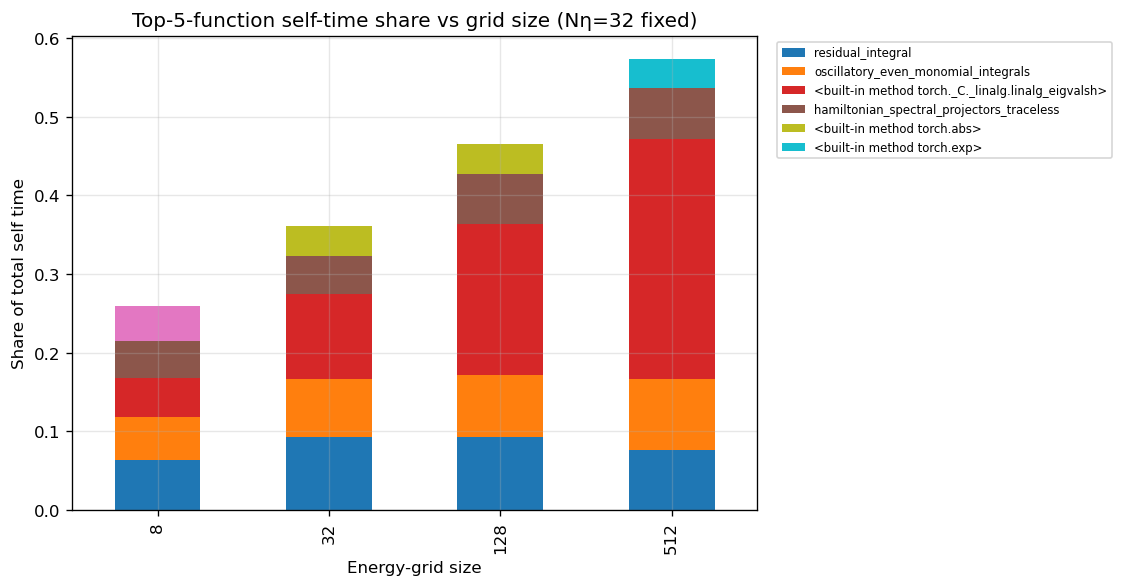

v:\output\benchmark\profiler_scaling_shares.png


In [10]:
SCALING_NE_SIZES = [8, 32, 128, 512]
SCALING_NETA = 32

scaling_records = []
top5_names_seen = []

for ne in SCALING_NE_SIZES:
    E_s = torch.linspace(0.5, 15.0, ne, dtype=DTYPE, device=DEVICE)
    eta_s = torch.linspace(0.05, torch.pi - 0.05, SCALING_NETA, dtype=DTYPE, device=DEVICE)

    def call(E_s=E_s, eta_s=eta_s):
        return earth_probability_state(
            MASS_WEIGHTS, earth_profile_t, oscillation,
            E_s[:, None], eta_s[None, :], EARTH_DEPTH_M,
            method="analytical", massbasis=True, context=context,
        )

    stats = profile_function(call, repeats=15, warmups=3)
    df = stats_to_dataframe(stats, limit=5, sort_by="tottime")
    for name in df["function"]:
        if name not in top5_names_seen:
            top5_names_seen.append(name)
    for _, row in df.iterrows():
        scaling_records.append({
            "n_energy": ne,
            "function": row["function"],
            "share": row["tottime_s"] / stats.total_tt,
        })

scaling_df = pd.DataFrame(scaling_records)
pivot = scaling_df.pivot_table(index="n_energy", columns="function", values="share", fill_value=0.0)
pivot = pivot[[c for c in top5_names_seen if c in pivot.columns]]
display(pivot)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("Energy-grid size")
ax.set_ylabel("Share of total self time")
ax.set_title(f"Top-5-function self-time share vs grid size (Nη={SCALING_NETA} fixed)")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1.0), loc="upper left")
fig.tight_layout()
save_and_show("profiler_scaling_shares.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 9. Summary

Combines the per-function `tottime` share from every profiled scenario above into one ranked table: which functions show up as expensive across the *most* scenarios, weighted by how much time they take in each.

,function,appears_in_n_scenarios,mean_share,max_share
15,<method 'pow' of 'torch._C.TensorBase' objects>,5,0.033665,0.069328
0,<built-in method torch._C._linalg.linalg_eigva...,4,0.284234,0.328113
27,hamiltonian_spectral_projectors_traceless,4,0.062945,0.070947
14,<built-in method torch.where>,4,0.034955,0.037565
24,evolutor_zero_order,4,0.023991,0.033064
16,<method 'sum' of 'torch._C.TensorBase' objects>,4,0.020727,0.027358
32,oscillatory_even_monomial_integrals,3,0.107337,0.126941
33,residual_integral,3,0.073722,0.081448
6,<built-in method torch.exp>,3,0.036974,0.042561
1,<built-in method torch.abs>,3,0.027107,0.031407


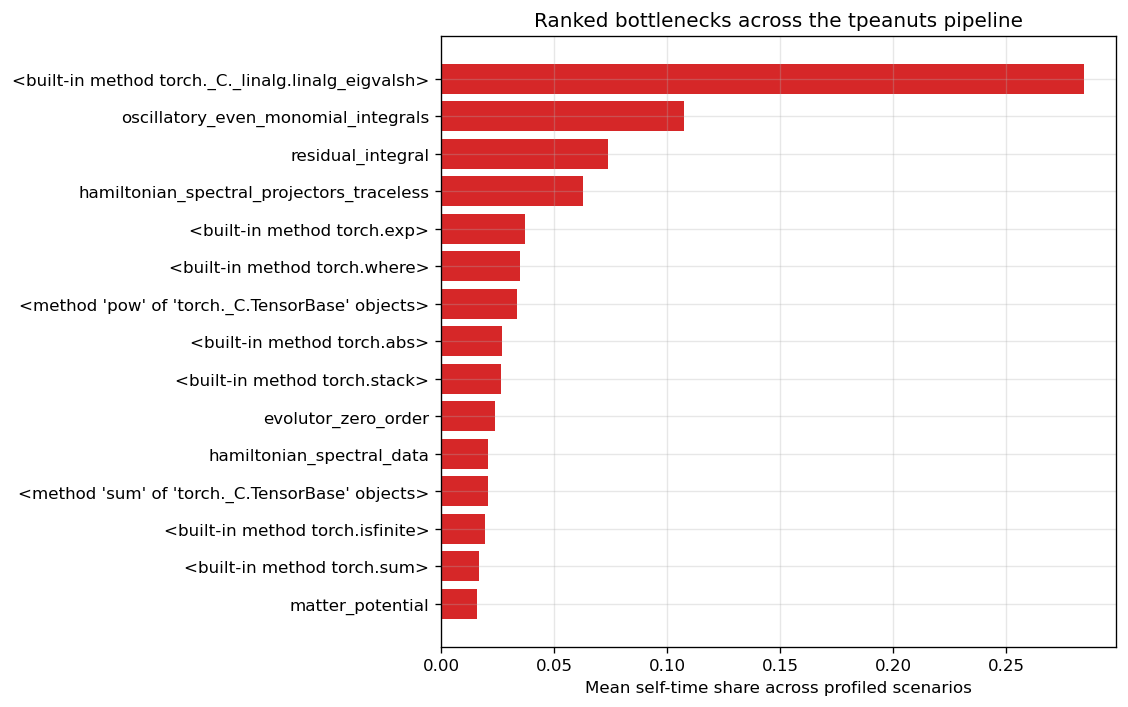

v:\output\benchmark\profiler_summary_ranked_bottlenecks.png
Saved: v:\output\benchmark\profiler_tpeanuts_summary.csv


In [11]:
scenario_dfs = {
    "solar_production": solar_df,
    "earth_propagation": earth_df,
    "solar_to_detector_chain": chain_df,
    "case_a_shell_crossing": case_a_df,
    "case_b_shallow": case_b_df,
}

combined_rows = []
for scenario, df in scenario_dfs.items():
    total = df.attrs.get("total_tottime_s") or df["tottime_s"].sum()
    for _, row in df.iterrows():
        combined_rows.append({
            "scenario": scenario,
            "function": row["function"],
            "location": row["location"],
            "share_of_scenario": row["tottime_s"] / total if total else 0.0,
        })
combined_df = pd.DataFrame(combined_rows)

summary = (
    combined_df.groupby("function", as_index=False)
    .agg(
        appears_in_n_scenarios=("scenario", "nunique"),
        mean_share=("share_of_scenario", "mean"),
        max_share=("share_of_scenario", "max"),
    )
    .sort_values(["appears_in_n_scenarios", "mean_share"], ascending=False)
)
display(summary.head(20))

fig, ax = plt.subplots(figsize=(9.5, 6.0))
top_summary = summary.head(15).sort_values("mean_share")
ax.barh(top_summary["function"], top_summary["mean_share"], color="C3")
ax.set_xlabel("Mean self-time share across profiled scenarios")
ax.set_title("Ranked bottlenecks across the tpeanuts pipeline")
fig.tight_layout()
save_and_show("profiler_summary_ranked_bottlenecks.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

summary.to_csv(OUTPUT_DIR / "profiler_tpeanuts_summary.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'profiler_tpeanuts_summary.csv'}")

## 10. Conclusions

This notebook locates the bottleneck functions of the tpeanuts solar-to-detector pipeline directly, rather than inferring them indirectly from end-to-end timing comparisons against a reference implementation (as `benchmark1`/`benchmark2` do). Section 7 in particular demonstrates concretely that the perturbative first-order correction (`evolutor_first_order`/`residual_integral`) is only exercised by Case-A (shell-crossing) trajectories, and is already skipped for Case-B (shallow, constant-density) trajectories rather than being computed and discarded. Section 8 separates genuine per-element computation from fixed per-call dispatch overhead by tracking how each function's time share evolves with grid size — the functions whose share shrinks as the grid grows are candidates for batching/fusion improvements that only matter at small grid sizes; the functions whose share stays flat or grows are the ones doing real, unavoidable work.